# **Base de Dados Câncer de Mama Wisconsin**

## **Configuração Inicial**

In [3]:
# ==============================================================================
# 1. IMPORTAÇÕES E CONFIGURAÇÕES GLOBAIS
# ==============================================================================

!pip install plotly seaborn kagglehub scikit-learn tensorflow yellowbrick --upgrade -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Pré-processamento e divisão de dados
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Modelos de Machine Learning
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Métricas de avaliação
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    classification_report, confusion_matrix
)

# Interpretabilidade e Redução de Dimensionalidade (Bibliotecas extras requeridas)
import umap
import shap

# Configurações visuais globais
sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(42) # Semente fixa para reprodutibilidade dos resultados

In [5]:
# ==============================================================================
# 2. FUNÇÕES AUXILIARES PARA GRÁFICOS E MÉTRICAS
# ==============================================================================

def plot_roc_pr(y_true, y_prob, titulo_prefixo=''):
    """Plota as curvas ROC (Receiver Operating Characteristic) e PR (Precision-Recall) lado a lado."""
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Gráfico 1: Curva ROC
    axes[0].plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.3f}')
    axes[0].plot([0, 1], [0, 1], '--', color='gray')
    axes[0].set(title=f'{titulo_prefixo}Curva ROC',
                xlabel='Falso Positivo (1-Especificidade)',
                ylabel='Verdadeiro Positivo (Sensibilidade)')
    axes[0].legend(loc='lower right')

    # Gráfico 2: Curva Precisão-Revocação (PR)
    axes[1].plot(rec, prec, label=f'PR-AUC = {pr_auc:.3f}', color='darkorange')
    axes[1].set(title=f'{titulo_prefixo}Curva Precisão-Revocação',
                xlabel='Revocação', ylabel='Precisão')
    axes[1].legend(loc='lower left')

    plt.tight_layout()
    plt.show()

def plot_confusion(y_true, y_pred, labels=('Benigno', 'Maligno'), titulo='Matriz de Confusão'):
    """Gera um Heatmap visual para a Matriz de Confusão."""
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm,
                         index=[f'Real {labels[0]}', f'Real {labels[1]}'],
                         columns=[f'Pred. {labels[0]}', f'Pred. {labels[1]}'])
    plt.figure(figsize=(4.5, 4))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(titulo)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

def compute_stats(y_true, y_pred, y_prob):
    """Calcula métricas detalhadas (Acurácia, Sensibilidade, Especificidade, F1, AUCs)."""
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    acc = (tp + tn) / (tp + tn + fp + fn)
    sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else np.nan
    roc = roc_auc_score(y_true, y_prob)
    pr = average_precision_score(y_true, y_prob)
    return {'Accuracy': acc, 'Sensitivity (Recall+)': sens, 'Specificity (Recall-)': spec,
            'F1': f1, 'ROC-AUC': roc, 'PR-AUC': pr}

In [6]:
# ==============================================================================
# 3. PREPARAÇÃO DA BASE DE DADOS (WDBC)
# ==============================================================================

# Download da base de dados via Kaggle
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")
wisconsin_base = pd.read_csv(path + '/data.csv')

# Limpeza das colunas não preditivas
wisconsin_base = wisconsin_base.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

# Transformação do Rótulo: 'B' (Benigno) -> 0 e 'M' (Maligno) -> 1
wisconsin_base['diagnosis'] = wisconsin_base['diagnosis'].map({'B': 0, 'M': 1})

# Separação entre as características (X) e a variável alvo (y)
X = wisconsin_base.drop(columns=['diagnosis'])
y = wisconsin_base['diagnosis']
feature_names = X.columns
target_names = ['Benigno', 'Maligno']

print('Formato de X:', X.shape)
print('Classes:', {0: 'Benigno', 1: 'Maligno'})

# Split estratificado: garante que a proporção de classes se mantenha no treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Padronização (Z-score): Essencial para a Regressão Logística, SVM, PCA e UMAP
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled_all = scaler.transform(X) # Utilizado posteriormente nas visualizações

print('Conjuntos criados - Treino:', X_train.shape, 'Teste:', X_test.shape)

Formato de X: (569, 30)
Classes: {0: 'Benigno', 1: 'Maligno'}
Conjuntos criados - Treino: (426, 30) Teste: (143, 30)


## **Estatística Básica**

In [7]:
wisconsin_base.info() # Coleta a quantidade de dados, a quantidade de não-nulos e o tipo do dado
wisconsin_base.describe() # Tira a estatística básica dos dados como média, desvio padrão, valor mínimo, primeiro quartil, mediana, terceiro quartil e valor máximo de cada coluna

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-null

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


<Axes: xlabel='diagnosis', ylabel='count'>

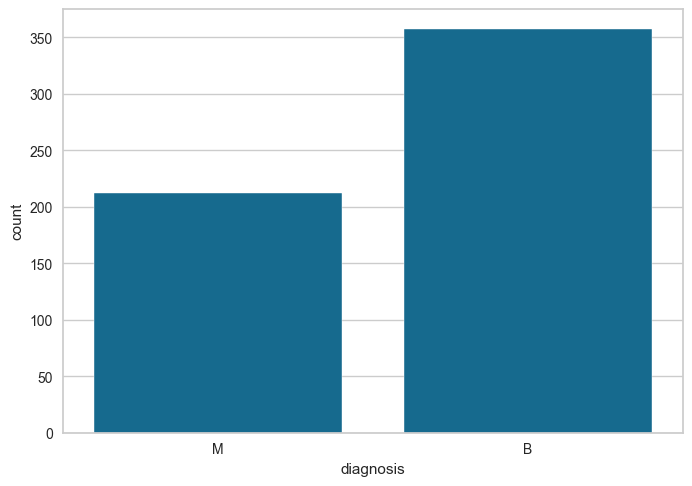

In [8]:
sns.countplot(x='diagnosis', data=wisconsin_base) # Gráfico que mostra a quantidade de cada valor da coluna 'diagnosis'

### ***Histogramas***

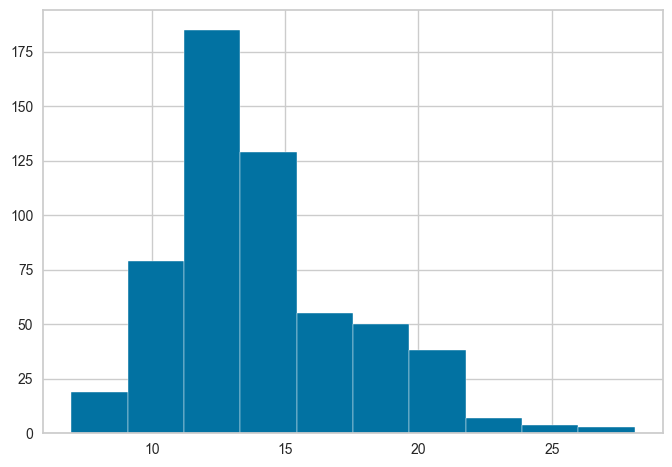

In [9]:
plt.hist(x= wisconsin_base['radius_mean']);

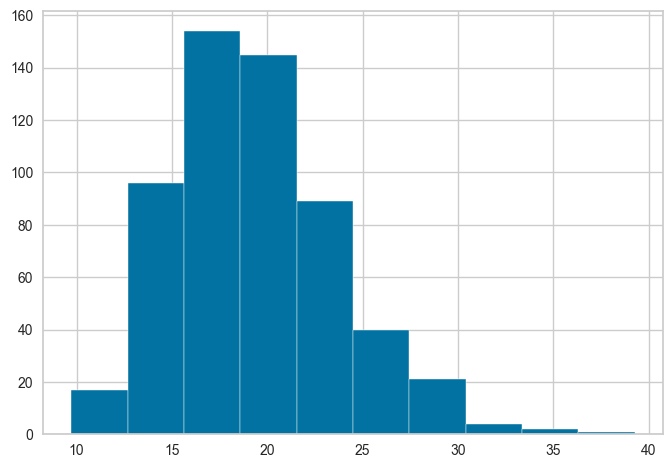

In [10]:
plt.hist(x= wisconsin_base['texture_mean']);

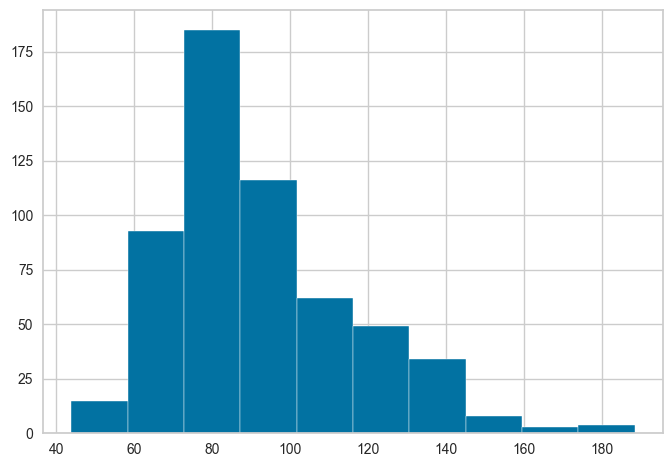

In [11]:
plt.hist(x= wisconsin_base['perimeter_mean']);

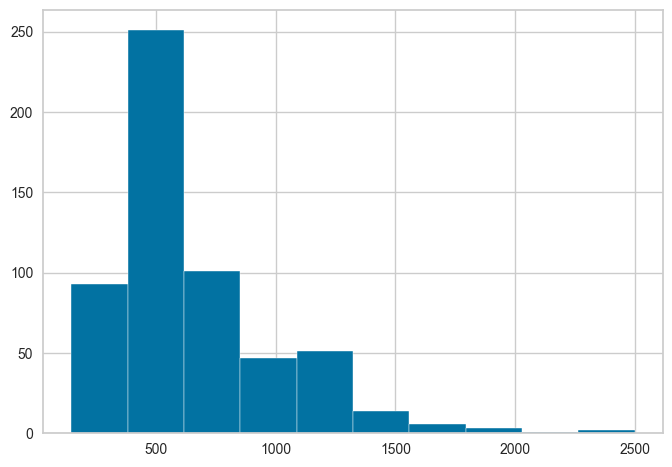

In [12]:
plt.hist(x= wisconsin_base['area_mean']);

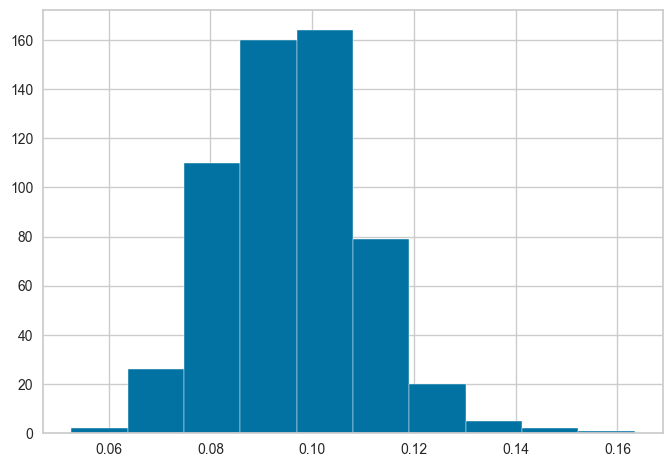

In [13]:
plt.hist(x= wisconsin_base['smoothness_mean']);

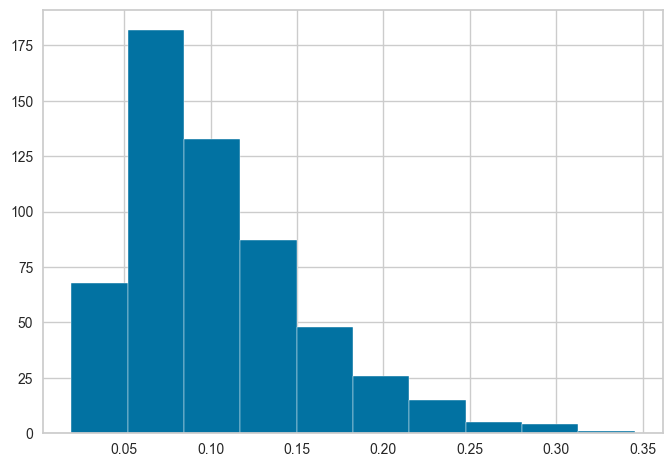

In [14]:
plt.hist(x= wisconsin_base['compactness_mean']);

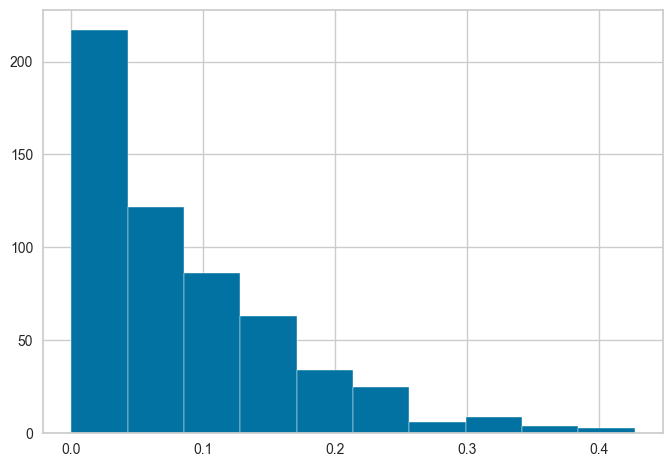

In [15]:
plt.hist(x= wisconsin_base['concavity_mean']);

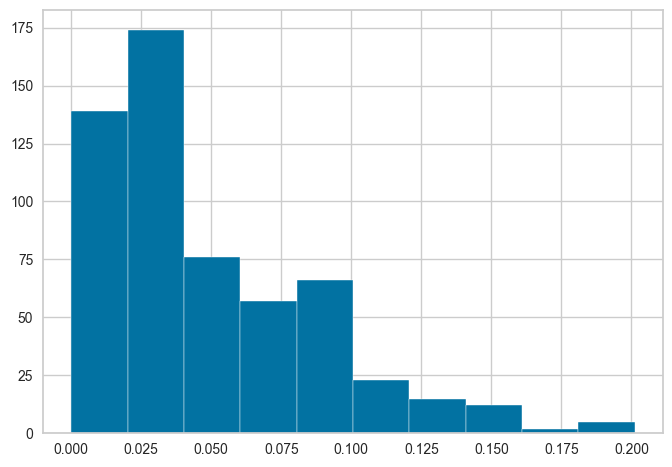

In [16]:
plt.hist(x= wisconsin_base['concave points_mean']);

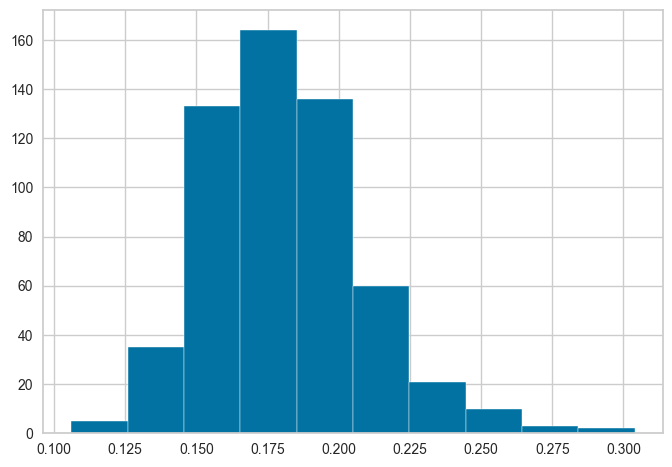

In [17]:
plt.hist(x= wisconsin_base['symmetry_mean']);

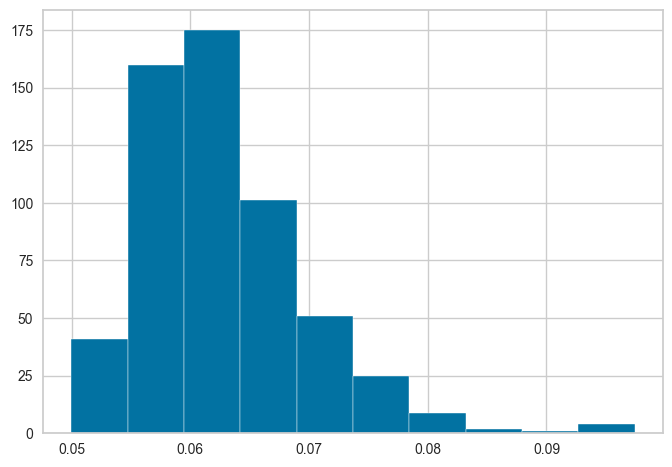

In [18]:
plt.hist(x= wisconsin_base['fractal_dimension_mean']);

### **BoxPlots**

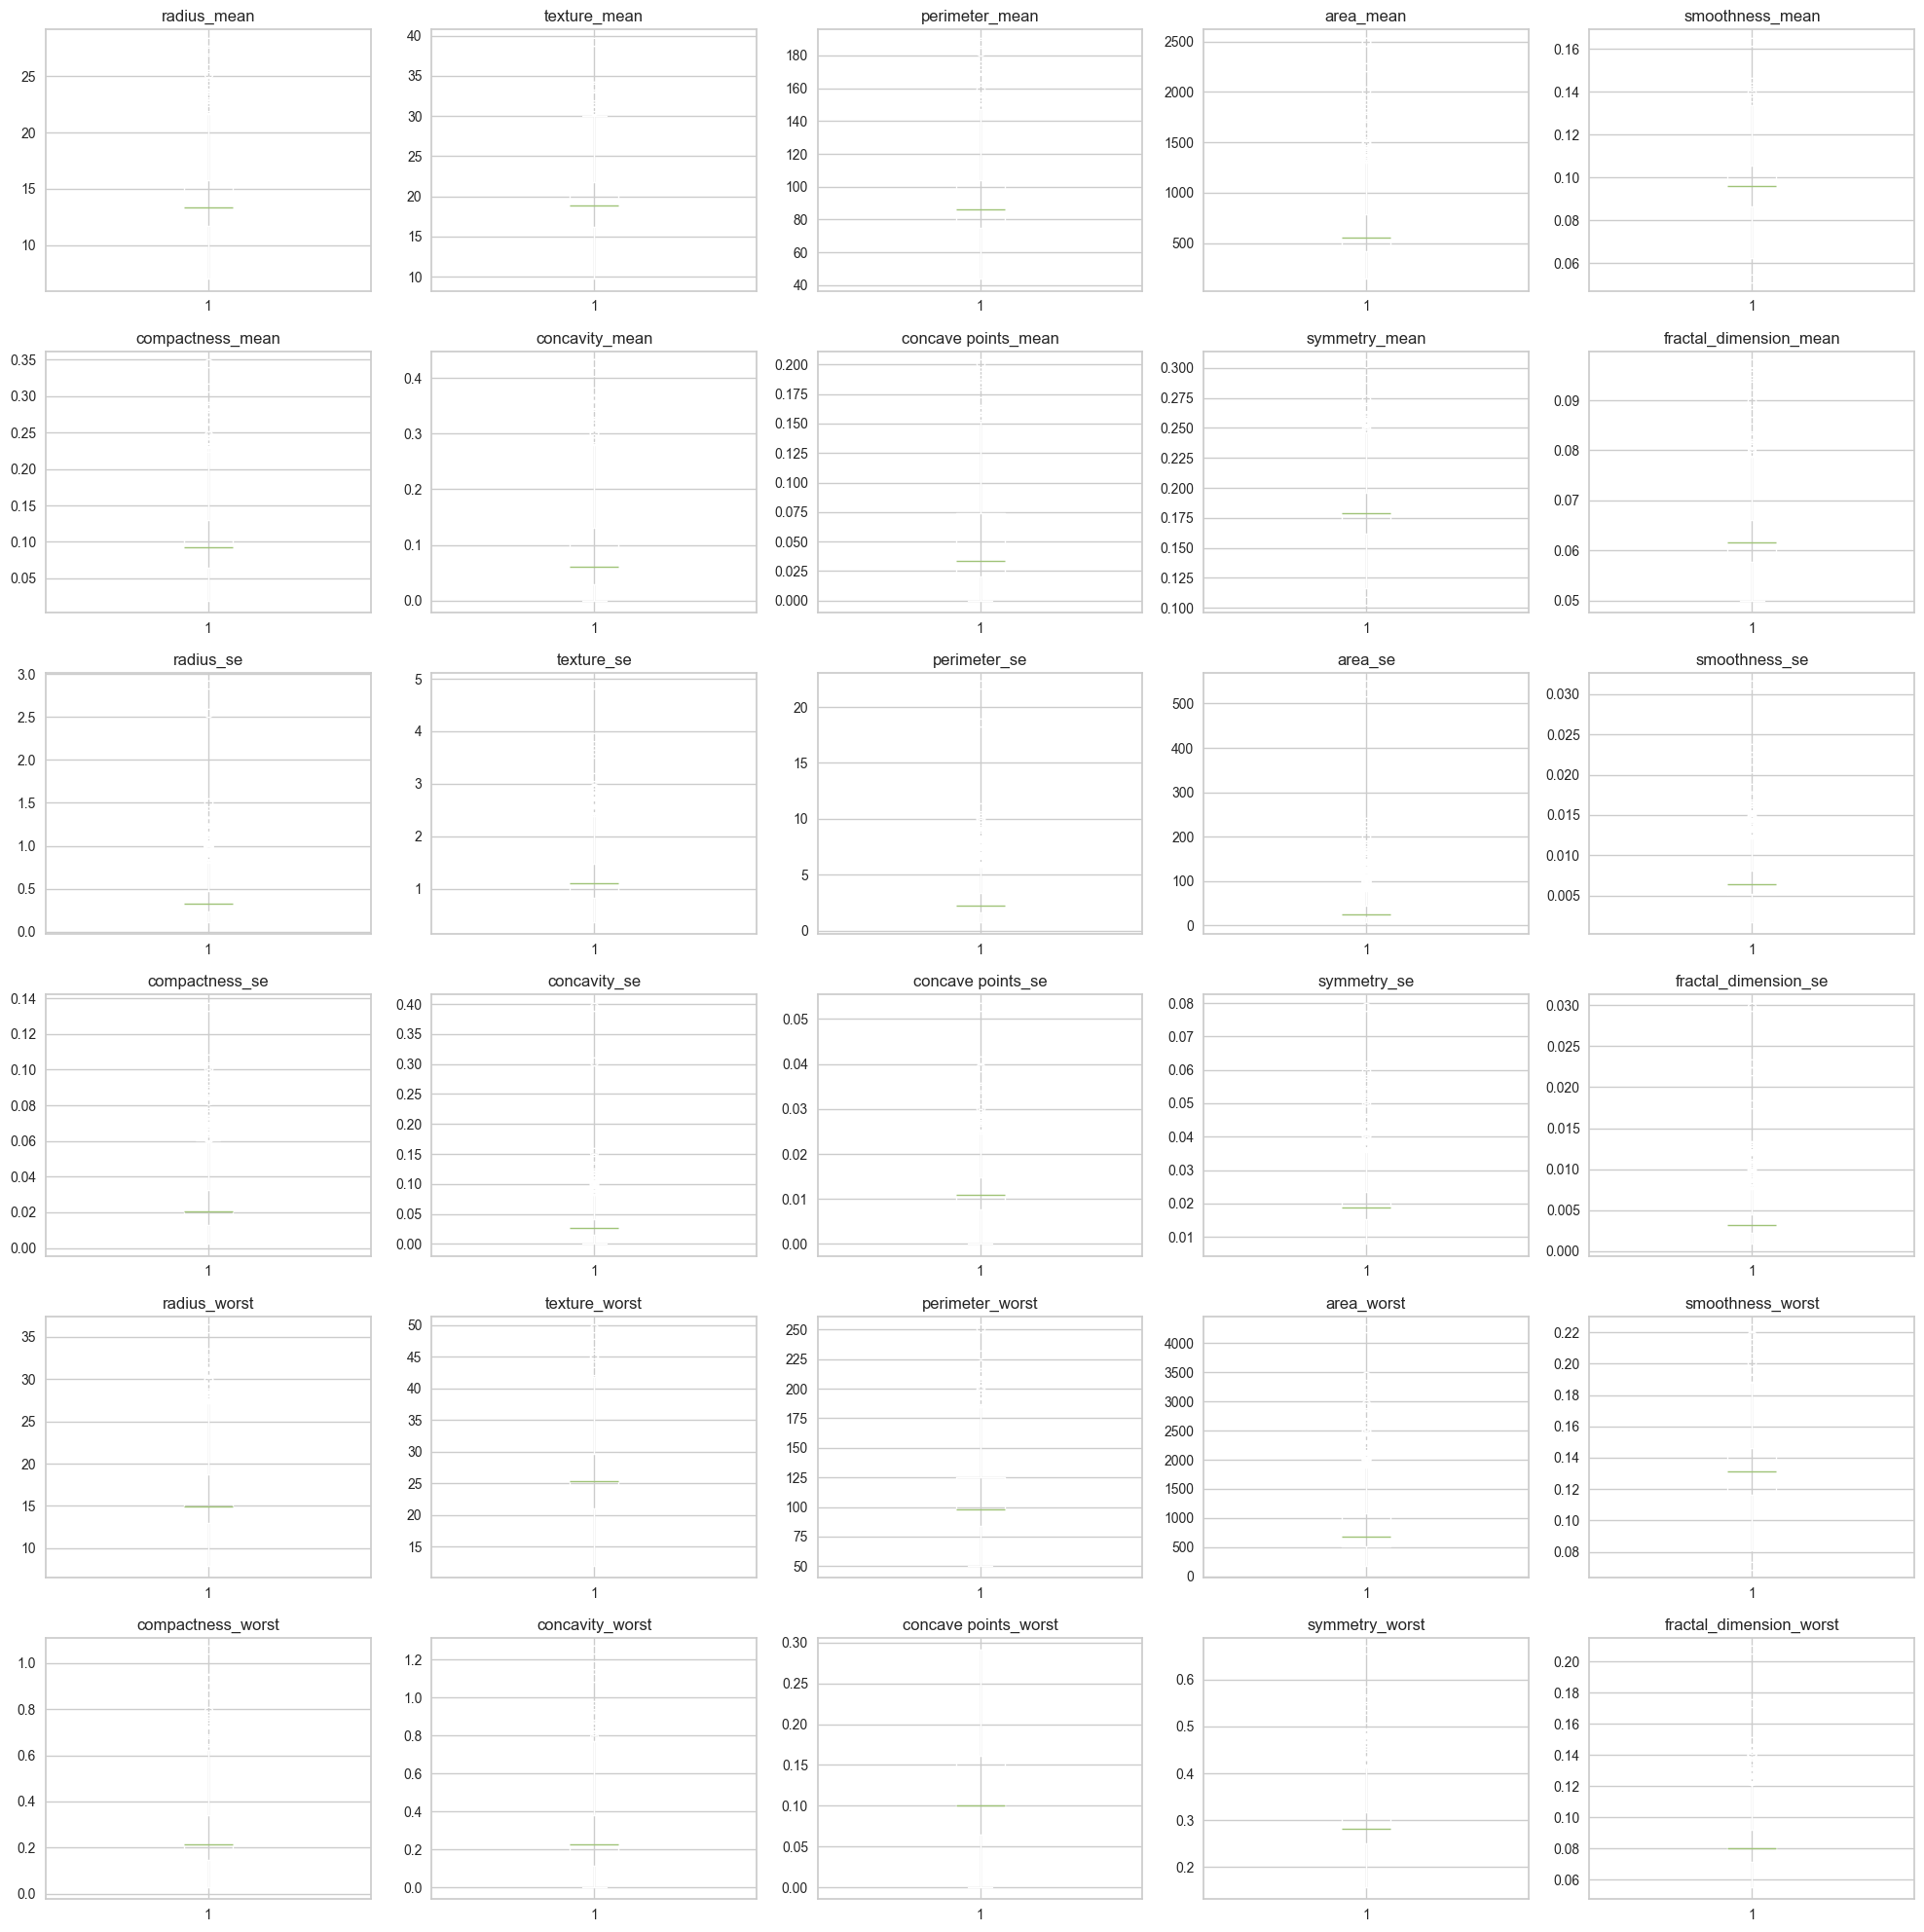

In [19]:
cols = wisconsin_base.columns[1:31]

fig, axes = plt.subplots(nrows=6, ncols=5, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].boxplot(wisconsin_base[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### *Pré-Processamento dos Dados*

In [34]:
# Divisão dos Previsores (será o X da função, o parâmetro com que iremos trabalhar)
x_wisconsin = wisconsin_base.iloc[:, 1:31].values
x_wisconsin

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]])

In [35]:
# Divisão da Classe (será o Y da função, o resultado que iremos analisar e conferir)
y_wisconsin = wisconsin_base.iloc[:, 0].values
y_wisconsin

<StringArray>
['M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M',
 ...
 'B', 'B', 'B', 'M', 'M', 'M', 'M', 'M', 'M', 'B']
Length: 569, dtype: str

In [36]:
# Escalonamento de valores (Normalização ou Padronização) nesse caso usaremos a padronização, pois lida muito melhor com outliers, que são informações cruciais para detectar anomalias em células.
scaler_wisconsin = StandardScaler()
x_wisconsin = scaler_wisconsin.fit_transform(x_wisconsin)

In [37]:
x_wisconsin

array([[ 1.09706398, -2.07333501,  1.26993369, ...,  2.29607613,
         2.75062224,  1.93701461],
       [ 1.82982061, -0.35363241,  1.68595471, ...,  1.0870843 ,
        -0.24388967,  0.28118999],
       [ 1.57988811,  0.45618695,  1.56650313, ...,  1.95500035,
         1.152255  ,  0.20139121],
       ...,
       [ 0.70228425,  2.0455738 ,  0.67267578, ...,  0.41406869,
        -1.10454895, -0.31840916],
       [ 1.83834103,  2.33645719,  1.98252415, ...,  2.28998549,
         1.91908301,  2.21963528],
       [-1.80840125,  1.22179204, -1.81438851, ..., -1.74506282,
        -0.04813821, -0.75120669]])

In [38]:
# Divisão da base de treinamento 0.8 para treino e 0.2 para teste. Usaremos a SEED 42 para todos os testes a seguir como convenção
x_wisconsin_train, x_wisconsin_test, y_wisconsin_train, y_wisconsin_test = train_test_split(x_wisconsin, y_wisconsin, test_size=0.2, random_state=42)

In [39]:
# Serialização para o Pickle, para não precisar realizar o pré-processamento toda vez que iniciarmos o notebook
with open('wisconsin.pkl', mode='wb') as f:
    pickle.dump([x_wisconsin_train, y_wisconsin_train, x_wisconsin_test, y_wisconsin_test], f)

## *Árvore de Decisão*

In [40]:
# Geração da árvore de decisão
wisconsin_decision_tree = DecisionTreeClassifier(criterion='entropy')
wisconsin_decision_tree.fit(x_wisconsin_train, y_wisconsin_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cu

In [46]:
# Retorna a importância de cada atributo
nome_colunas = ['radius_mean','texture_mean','perimeter_mean','area_mean','smoothness_mean','compactness_mean','concavity_mean','concave points_mean','symmetry_mean','fractal_dimension_mean','radius_se','texture_se','perimeter_se','area_se','smoothness_se','compactness_se','concavity_se','concave points_se','symmetry_se','fractal_dimension_se','radius_worst','texture_worst','perimeter_worst','area_worst','smoothness_worst','compactness_worst','concavity_worst','concave points_worst','symmetry_worst','fractal_dimension_worst']

# Pega os valores de importância gerados pela sua árvore
importancias = wisconsin_decision_tree.feature_importances_

# Cria o DataFrame juntando a lista 'nome_colunas' com os valores de importância
df_importancias = pd.DataFrame({
    'Atributo': nome_colunas,
    'Importância': importancias
})

# Exibe a tabela formatada e pronta para o TCC
display(df_importancias)

,Atributo,Importância
0,concave points_mean,0.588917
1,perimeter_worst,0.105379
2,radius_worst,0.092874
3,texture_worst,0.085717
4,concave points_worst,0.026620
5,texture_mean,0.024489
6,radius_se,0.021612
7,concave points_se,0.018594
8,perimeter_se,0.016579
9,perimeter_mean,0.012857


[Text(0.5875, 0.9375, 'concave points_mean <= 0.061\nentropy = 0.952\nsamples = 455\nvalue = [286, 169]\nclass = B'),
 Text(0.325, 0.8125, 'radius_worst <= 0.116\nentropy = 0.314\nsamples = 282\nvalue = [266, 16]\nclass = B'),
 Text(0.45625000000000004, 0.875, 'True  '),
 Text(0.2, 0.6875, 'radius_se <= 0.795\nentropy = 0.136\nsamples = 263\nvalue = [258, 5]\nclass = B'),
 Text(0.1, 0.5625, 'texture_worst <= 0.728\nentropy = 0.091\nsamples = 260\nvalue = [257, 3]\nclass = B'),
 Text(0.05, 0.4375, 'entropy = 0.0\nsamples = 225\nvalue = [225, 0]\nclass = B'),
 Text(0.15, 0.4375, 'radius_worst <= -0.381\nentropy = 0.422\nsamples = 35\nvalue = [32, 3]\nclass = B'),
 Text(0.1, 0.3125, 'entropy = 0.0\nsamples = 25\nvalue = [25, 0]\nclass = B'),
 Text(0.2, 0.3125, 'perimeter_mean <= -0.235\nentropy = 0.881\nsamples = 10\nvalue = [7, 3]\nclass = B'),
 Text(0.15, 0.1875, 'perimeter_se <= -0.712\nentropy = 0.811\nsamples = 4\nvalue = [1, 3]\nclass = M'),
 Text(0.1, 0.0625, 'entropy = 0.0\nsample

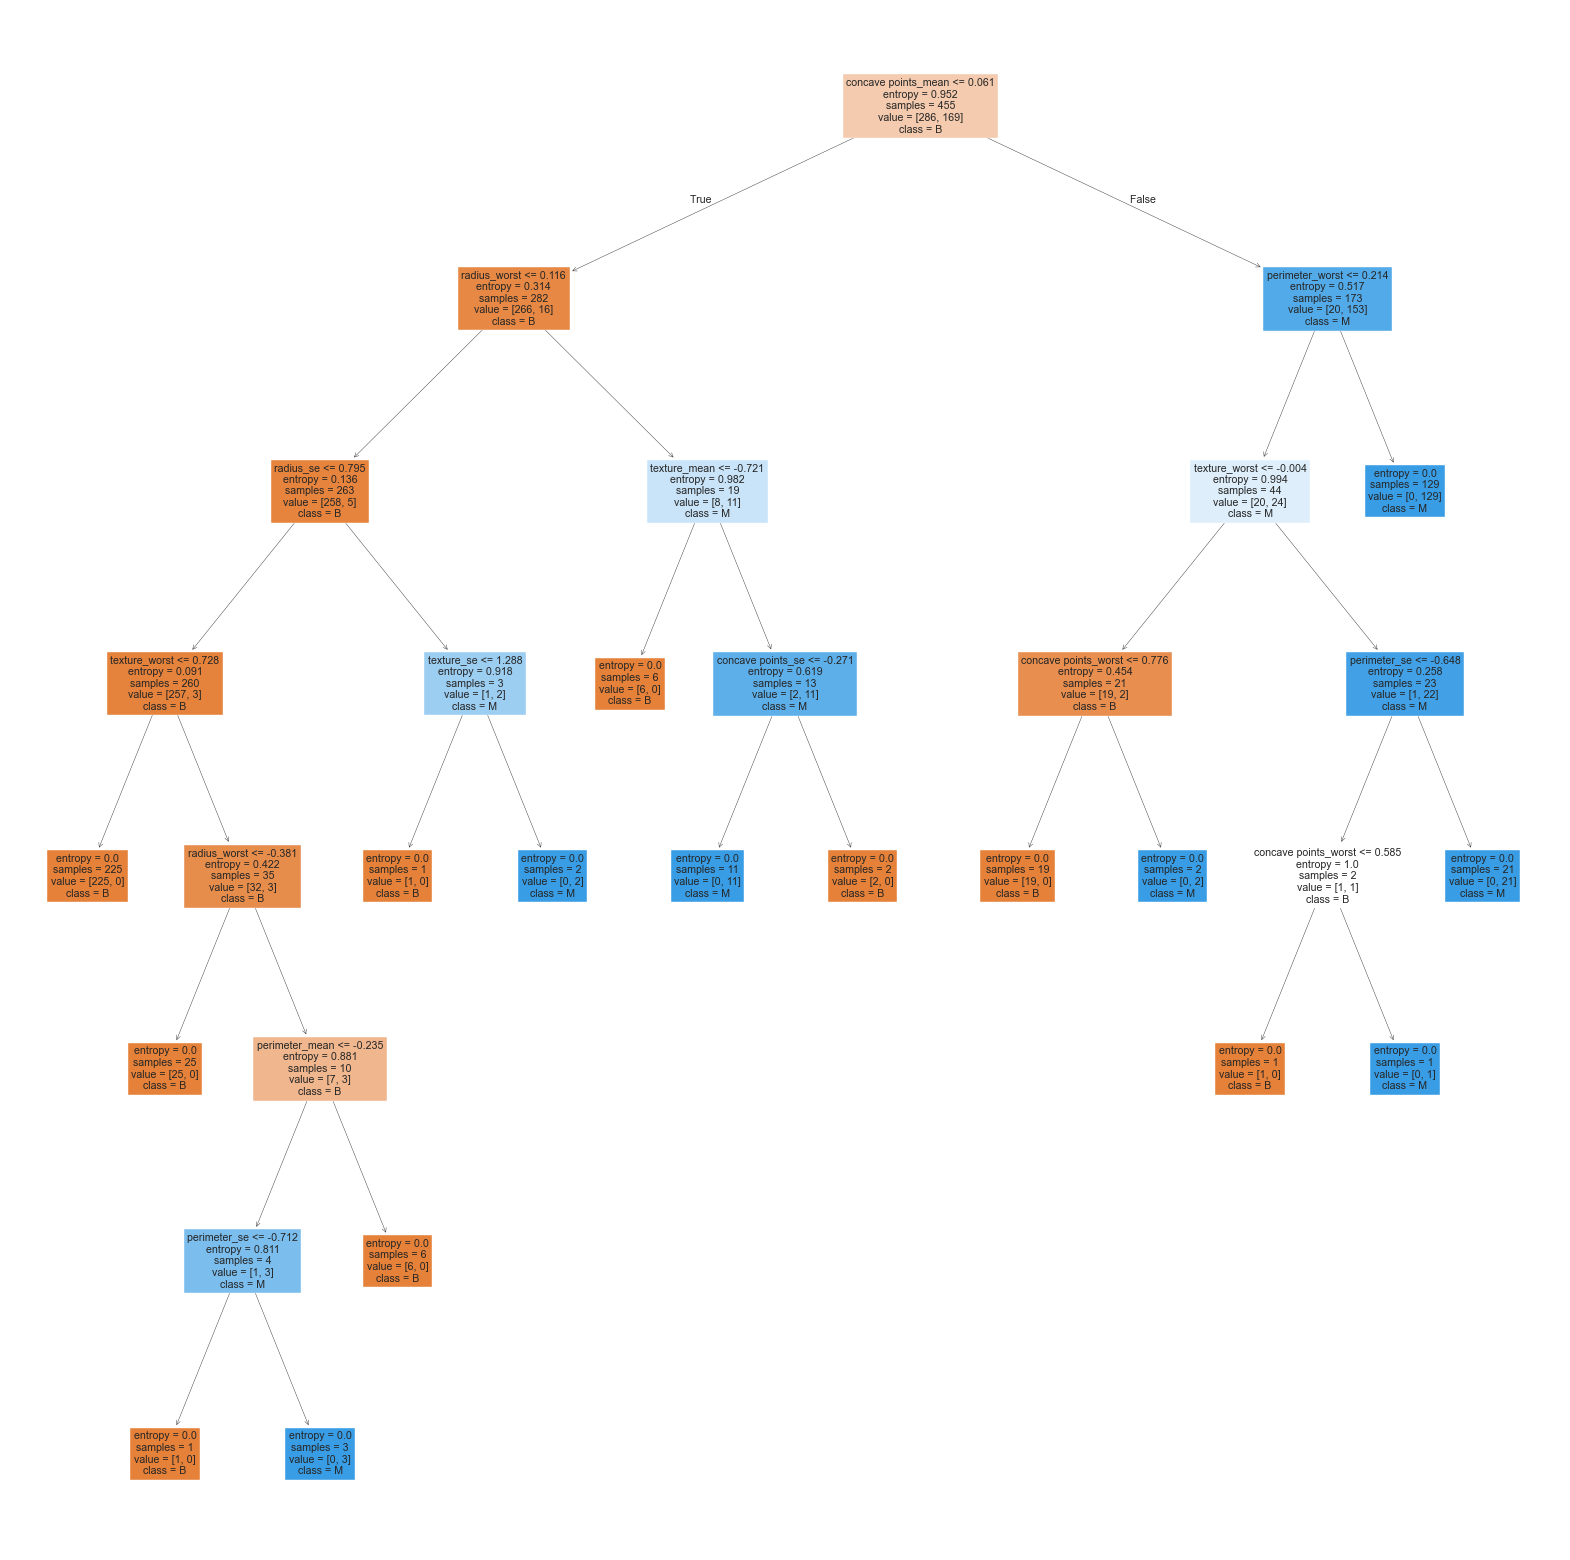

In [54]:
# Comando para aumentar tamanho da imagem
figura = plt.subplots(nrows=1, ncols=1, figsize=(20, 20))

# Imprime a árvore passando o nome das colunas, a classe ("B" ou "M"), e o filled adiciona cores
tree.plot_tree(wisconsin_decision_tree, feature_names=nome_colunas, class_names=wisconsin_decision_tree.classes_, filled=True) # O ponto e vírgula no final esconde o texto

In [ ]:
# Agora vamos tentar prever um resultado da base de teste (Essa árvore não foi treinada com os dados que passarei a seguir)
# x_wisconsin_test
# y_wisconsin_test

previsao = wisconsin_decision_tree.predict(x_wisconsin_test)
previsao

In [ ]:
# Vamos comparar os resultados da previsão com os resultados reais do teste y_wisconsin_test

# Teste de acurácia
# accuracy_score(y_wisconsin_test, previsao)

# # Matriz de confusão
# cm = ConfusionMatrix(y_wisconsin, previsao)
# cm.fit(x_wisconsin_train, y_wisconsin_train)
# cm.score(x_wisconsin_test, y_wisconsin_test)

# Classification Report
print(classification_report(y_wisconsin_test, previsao))

## *Treinamento e Avaliação (LogReg, RF e SVM)*

=== Regressão Logística ===
Relatório de Classificação:
               precision    recall  f1-score   support

     Benigno       0.97      0.99      0.98        90
     Maligno       0.98      0.94      0.96        53

    accuracy                           0.97       143
   macro avg       0.97      0.97      0.97       143
weighted avg       0.97      0.97      0.97       143



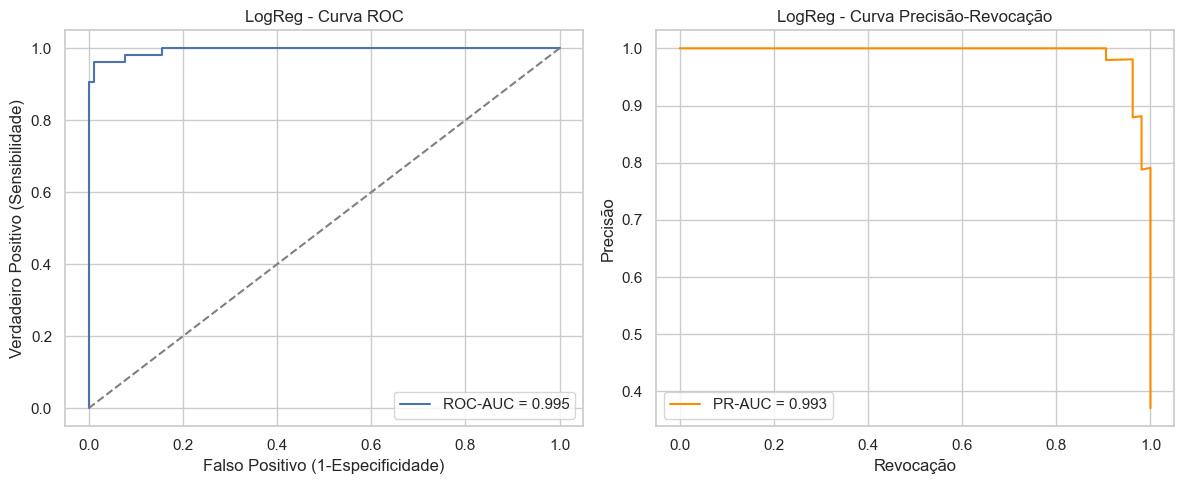

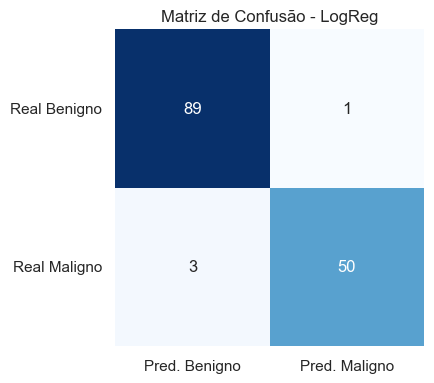


=== Random Forest ===
Relatório de Classificação:
               precision    recall  f1-score   support

     Benigno       0.96      1.00      0.98        90
     Maligno       1.00      0.92      0.96        53

    accuracy                           0.97       143
   macro avg       0.98      0.96      0.97       143
weighted avg       0.97      0.97      0.97       143



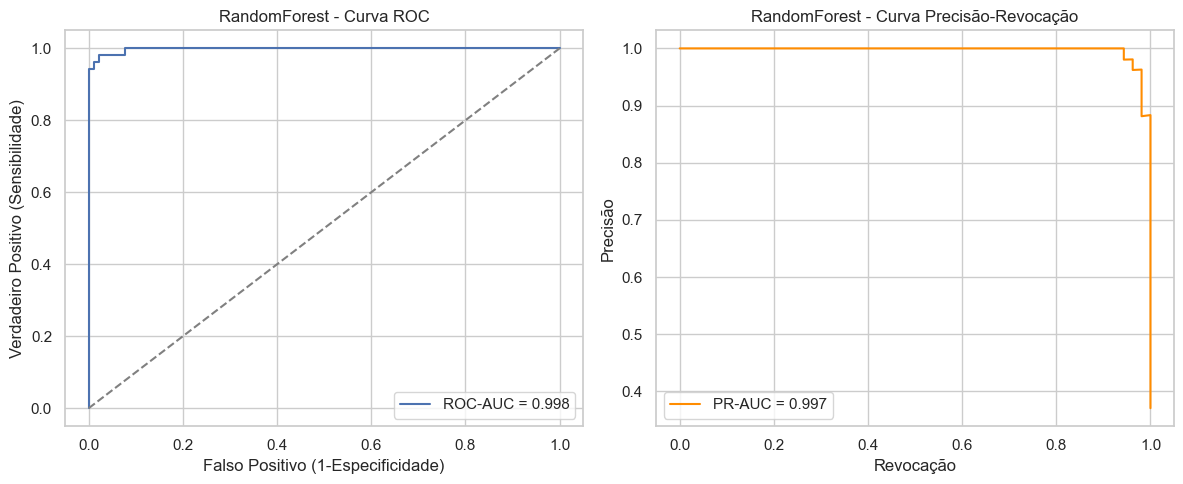

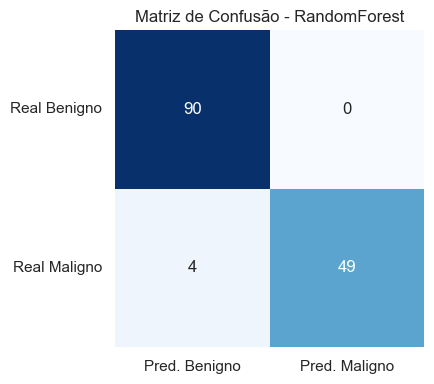


=== SVM (RBF) ===
Relatório de Classificação:
               precision    recall  f1-score   support

     Benigno       0.99      1.00      0.99        90
     Maligno       1.00      0.98      0.99        53

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



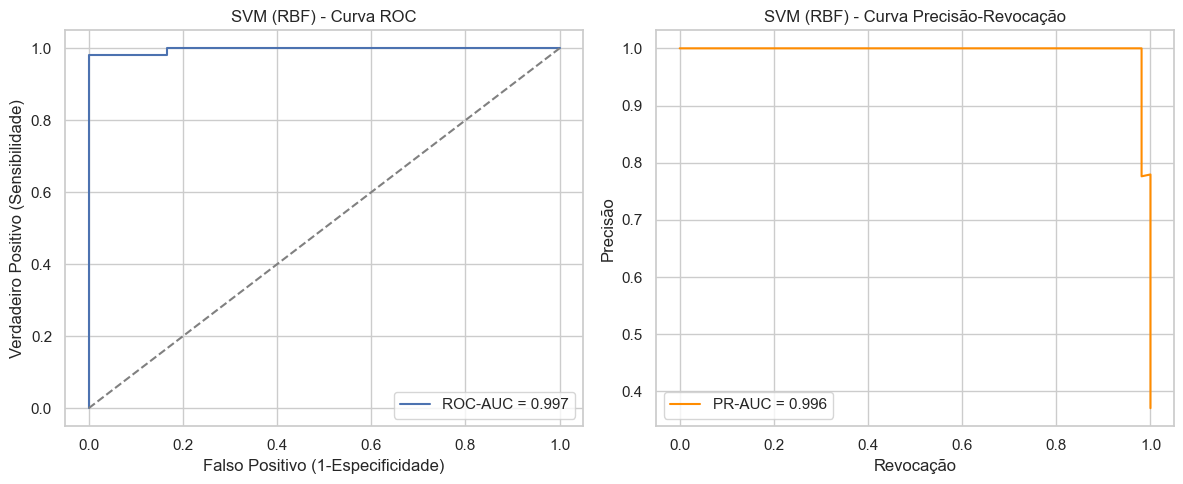

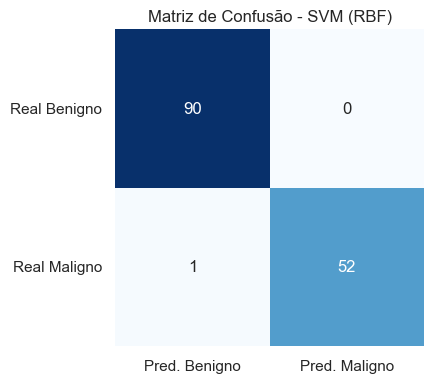


=== Resumo de Métricas (Teste) ===


,Accuracy,Sensitivity (Recall+),Specificity (Recall-),F1,ROC-AUC,PR-AUC
LogReg,0.972,0.9434,0.9889,0.9615,0.9950,0.9927
RandomForest,0.972,0.9245,1.0000,0.9608,0.9979,0.9967
SVM (RBF),0.993,0.9811,1.0000,0.9905,0.9969,0.9958


In [7]:
# ==============================================================================
# 4. TREINAMENTO E AVALIAÇÃO (LogReg, Random Forest e SVM)
# ==============================================================================

# --- 1. Regressão Logística ---
logreg = LogisticRegression(max_iter=2000, class_weight='balanced', solver='lbfgs')
logreg.fit(X_train_scaled, y_train)
proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]
pred_lr = (proba_lr >= 0.5).astype(int)

print('=== Regressão Logística ===')
print('Relatório de Classificação:\n', classification_report(y_test, pred_lr, target_names=target_names))
plot_roc_pr(y_test, proba_lr, titulo_prefixo='LogReg - ')
plot_confusion(y_test, pred_lr, titulo='Matriz de Confusão - LogReg')

# --- 2. Random Forest ---
rf = RandomForestClassifier(n_estimators=500, random_state=42, class_weight='balanced', n_jobs=-1)
rf.fit(X_train_scaled, y_train)
proba_rf = rf.predict_proba(X_test_scaled)[:, 1]
pred_rf = (proba_rf >= 0.5).astype(int)

print('\n=== Random Forest ===')
print('Relatório de Classificação:\n', classification_report(y_test, pred_rf, target_names=target_names))
plot_roc_pr(y_test, proba_rf, titulo_prefixo='RandomForest - ')
plot_confusion(y_test, pred_rf, titulo='Matriz de Confusão - RandomForest')

# --- 3. SVM (Support Vector Machine com kernel RBF) ---
svm = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
svm.fit(X_train_scaled, y_train)
proba_svm = svm.predict_proba(X_test_scaled)[:, 1]
pred_svm = (proba_svm >= 0.5).astype(int)

print('\n=== SVM (RBF) ===')
print('Relatório de Classificação:\n', classification_report(y_test, pred_svm, target_names=target_names))
plot_roc_pr(y_test, proba_svm, titulo_prefixo='SVM (RBF) - ')
plot_confusion(y_test, pred_svm, titulo='Matriz de Confusão - SVM (RBF)')

# --- Resumo Final ---
results = pd.DataFrame({
    'LogReg': compute_stats(y_test, pred_lr, proba_lr),
    'RandomForest': compute_stats(y_test, pred_rf, proba_rf),
    'SVM (RBF)': compute_stats(y_test, pred_svm, proba_svm),
}).T.round(4)

print('\n=== Resumo de Métricas (Teste) ===')
display(results)

## *Visualização de Estrutura (UMAP E PCA)*

/Users/gabrielastdossantos/PyCharmProject/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


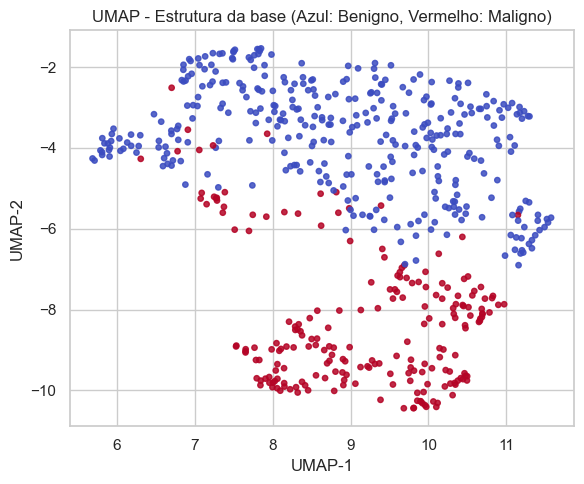

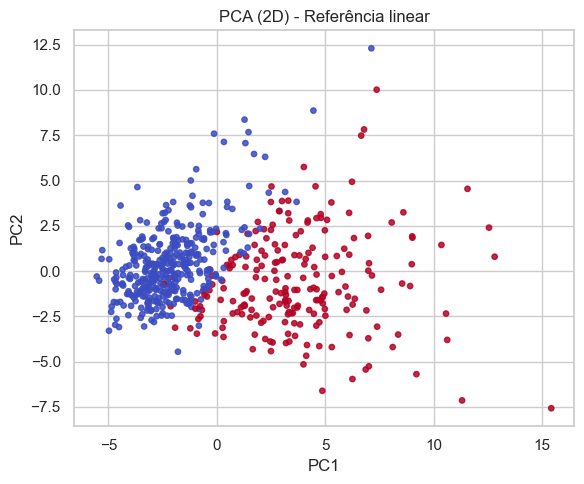

In [8]:
# ==============================================================================
# 5. VISUALIZAÇÃO DE ESTRUTURA (UMAP e PCA)
# ==============================================================================

# UMAP: Boa capacidade para encontrar agrupamentos locais complexos
reducer = umap.UMAP(random_state=42, n_neighbors=15, min_dist=0.1)
emb = reducer.fit_transform(X_scaled_all)

plt.figure(figsize=(6, 5))
scatter = plt.scatter(emb[:, 0], emb[:, 1], c=y, cmap='coolwarm', s=15, alpha=0.85)
plt.title('UMAP - Estrutura da base (Azul: Benigno, Vermelho: Maligno)')
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.tight_layout()
plt.show()

# PCA: Redução linear tradicional para comparação
pca_emb = PCA(n_components=2, random_state=42).fit_transform(X_scaled_all)

plt.figure(figsize=(6, 5))
plt.scatter(pca_emb[:, 0], pca_emb[:, 1], c=y, cmap='coolwarm', s=15, alpha=0.85)
plt.title('PCA (2D) - Referência linear')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

## *Interpretabilidade do Modelo (SHAP)*

 95%|=================== | 1080/1138 [00:15<00:00]       

=== Importância Global das Variáveis ===


/var/folders/sx/n9rwnlfn5yg43j974vcjp1x40000gn/T/ipykernel_5686/2061629136.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_scaled_all, feature_names=feature_names)
/Users/gabrielastdossantos/PyCharmProject/lib/python3.11/site-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/Users/gabrielastdossantos/PyCharmProject/lib/python3.11/site-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in

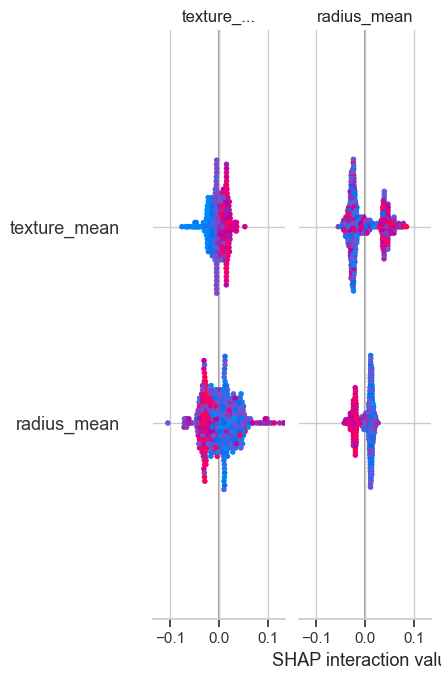


=== Explicação Local (Exemplo de um paciente) ===
Probabilidade prevista de câncer maligno para o paciente no índice 0: 97.2 %


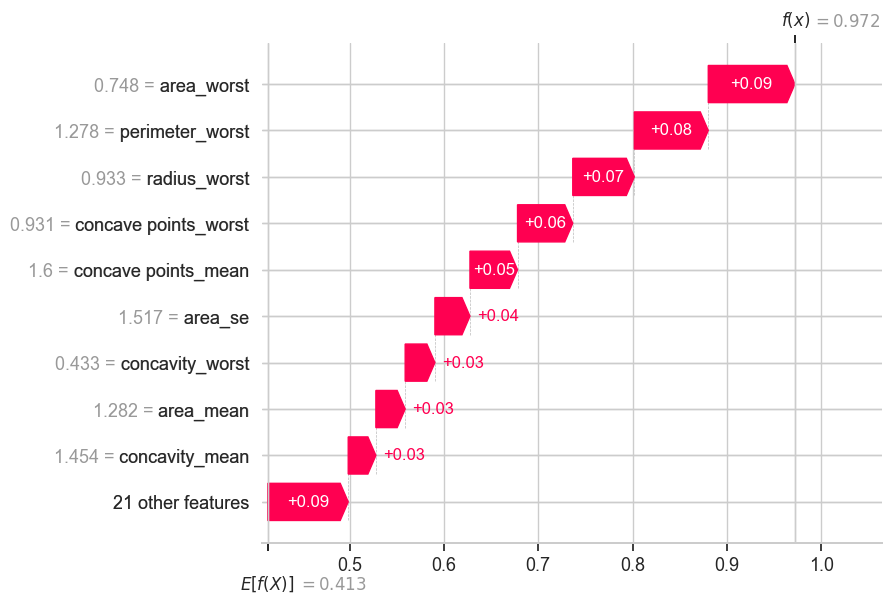

In [9]:
# ==============================================================================
# 6. INTERPRETABILIDADE DO MODELO (SHAP)
# ==============================================================================

# O SHAP explica o modelo Random Forest treinado com todos os dados
rf_all = RandomForestClassifier(
    n_estimators=500, random_state=42,
    class_weight='balanced', n_jobs=-1
).fit(X_scaled_all, y)

explainer = shap.Explainer(rf_all, X_scaled_all)
shap_values = explainer(X_scaled_all)

print('=== Importância Global das Variáveis ===')
# Cria o Summary Plot revelando as "features" mais decisivas
shap.summary_plot(shap_values, X_scaled_all, feature_names=feature_names)

print('\n=== Explicação Local (Exemplo de um paciente) ===')
# Explicação detalhada de como o modelo avaliou a amostra 0 do teste
idx = 0
x0 = X_test_scaled[idx:idx + 1]
sv0 = explainer(x0)

print(f"Probabilidade prevista de câncer maligno para o paciente no índice {idx}:",
      round(rf_all.predict_proba(x0)[0, 1] * 100, 2), "%")

# Waterfall plot focado especificamente na probabilidade da classe 1 (Maligno)
single_explanation = shap.Explanation(
    values=sv0.values[0, :, 1],
    base_values=sv0.base_values[0, 1],
    data=sv0.data[0],
    feature_names=feature_names
)
shap.plots.waterfall(single_explanation)